# Aprendizaje Profundo
## Tarea 2: Redes convolucionales y transferencia
### Eduardo García Alarcón - PCIC
#### Ejercicio 1 - Operación de Convolución
Extiende la operación de convolución para imágenes en escala de grises (un solo canal) vista en clase (https://github.com/gibranfp/CursoAprendizajeProfundo/blob/2025-1/notebooks/2a_convolucion.ipynb) a imágenes a color (múltiples canales).

In [1]:
# Bibliotecas 図書館
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(42)

### Cargamos una imagen
En este caso se usará la foto que uso para casi todo como foto de perfil, por lo que se llama *perfil.jpg*

In [2]:
image = plt.imread("perfil.jpg", format='jpeg')

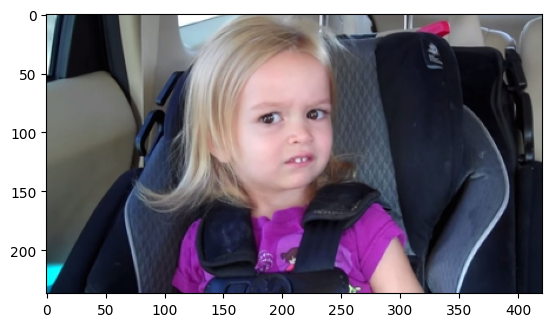

In [3]:
plt.imshow(image)
plt.show()

In [4]:
print(f"Las dimensiones de la imagen son: {image.shape}")
print(f"El valor mínimo es: {image.min()}")
print(f"El valor máximo es: {image.max()}")


Las dimensiones de la imagen son: (237, 421, 3)
El valor mínimo es: 0
El valor máximo es: 255


### Podemos ver que la imagen tiene valores RGB que van de 0 a 255
Por lo que podemos hacer una normalización entre 0 y 1 con una simple división

In [5]:
image = image/image.max()

### Tomando como base lo de la clase/Notebook
Sabemos que la diferencia entre blanco y negro y RGB es que en vez de ser un solo de grises, tenemos 3 canales correspondientes a *Red, Green, Blue*.
Esto nos incita a pensar que necesitamos una suma de esos tres canales; por lo que necesitaremos iterar durante la convolución.

Ahora consideremos la operación de convolución entre una imagen $I$ (RGB) y un filtro $W$, que tiene 3 canales (que son iguales). La convolución en este caso está definida por:

$$
A_{i,j,k} = (\mathbf{I} * \mathbf{W})_{i,j,k} = \sum_{o} \sum_m \sum_n I_{m, n, o} W_{i - m, j - n, k-o}
$$

donde $( k )$ recorre los tres canales de la imagen y el filtro, y $( A_{i,j,k})$ es el valor de la activación resultante en la posición $(i,j,k)$.

La convolución sigue siendo conmutativa, por lo que podemos reordenar los términos de la siguiente manera:

$$
A_{i,j,k} = (\mathbf{W} * \mathbf{I})_{i,j,k} = \sum_{o} \sum_m \sum_n I_{i - m, j - n, k - o} W_{m,n,o}
$$

En lugar de la convolución, frecuentemente se utiliza la operación de correlación cruzada para llevar a cabo las capas convolucionales. Esta operación es similar a la convolución, pero sin voltear el filtro, lo que hace que pierda la propiedad de conmutatividad. En el caso de imágenes RGB, la correlación cruzada está dada por:

$$
A_{i,j,k} = (\mathbf{W} * \mathbf{I})_{i,j,k} = \sum_{o} \sum_m \sum_n I_{i + m, j + n, k + o} W_{m,n,o}
$$

El resultado de estas operaciones es el mapa de activaciones $A(i,j,k)$.


In [6]:
def conv2d(I, W, b, stride=1):
  # height
  h_s = int(np.floor((I.shape[0] - W.shape[0]) / stride)) + 1
  # width
  w_s = int(np.floor((I.shape[1] - W.shape[1]) / stride)) + 1
  a = np.zeros((h_s, w_s))
  for i in range(h_s):
    for j in range(w_s):
      # Obtenemos la ventana
      I_m = I[i*stride:i*stride+W.shape[0], 
              j*stride:j*stride+W.shape[1]] 
      # La operación sum() hace la suma en todas las dimensiones
      #   por lo que está sumando los valores de entre canales
      #   y los valores de los 3 canales
      a[i,j] = (I_m * W).sum() + b
  return a


### Definimos un filtro

In [7]:
W = np.zeros((3,3,3))
# Hacemos diagionales
W[0,0,:] = 1
W[1,1,:] = 1
W[2,2,:] = 1

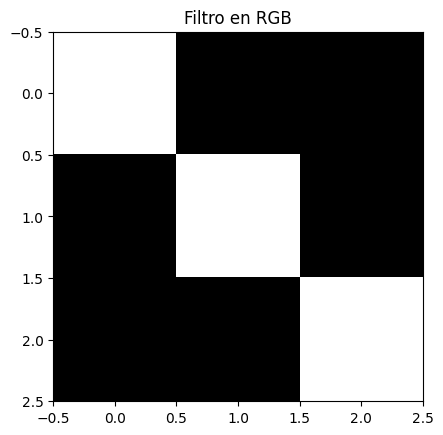

In [8]:
plt.title("Filtro en RGB")
plt.imshow(W)
plt.show()

In [9]:
# Definimos la función de activación
sigmoid = lambda z: 1. / (1. + np.exp(-z))

In [10]:
a = sigmoid(conv2d(image, W, 0))

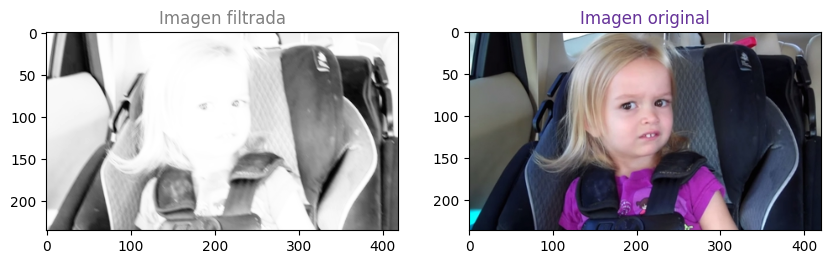

In [11]:
plt.figure(figsize=(10,15))
plt.subplot(1,2,1)
plt.gca().set_title("Imagen filtrada", color='gray')
plt.imshow(a, cmap='gray')
plt.subplot(1,2,2)
plt.gca().set_title("Imagen original", color='rebeccapurple')
plt.imshow(image)
plt.show()

### Como podemos observar, el filtro que hicimos resalta las diagonales de izquierda a derecha, por lo que tiene sentido que hayamos perdido el detalle en su cabello que en general va en diagonal de derecha a izquierda